# Storage ($G'$) and Loss ($G''$) Moduli

We can calculate the storage and loss moduli on the smooth $G(t)$ using (https://pubs.acs.org/doi/10.1021/acs.macromol.3c01893?ref=pdf)


$$G^\prime(\omega) = \omega \int_0^\infty G(t)\sin(\omega t) dt$$

$$G^{\prime\prime}(\omega) = \omega \int_0^\infty G(t)\cos(\omega t) dt$$


In [42]:
import numpy as np

def storage_modulus(omega, G, t, integration_points=5000):
    """
    Compute the storage modulus for a given frequency, G(t), and number of integration points.
    Parameters:
    omega : float
        Frequency at which to compute the storage modulus.
    G : array_like
        Relaxation modulus values at times t.
    t : array_like
        Time values corresponding to G.
    integration_points : int
        Number of points to use in the numerical integration.
    """

    # Resample G(t) onto a finer grid for integration
    t_int = np.linspace(t[0], t[-1], integration_points)
    G_int = np.interp(t_int, t, G)

    # print(len(t_int), len(G_int))

    integrand = G_int * np.sin(omega * t_int)
    # print(omega * t_int)
    # print(np.sin(omega * t_int))
    # print(integrand)
    # print(np.trapezoid(integrand, t_int))
    return omega * np.trapezoid(integrand, t_int)

We must first look for a smooth region to calculate this on.



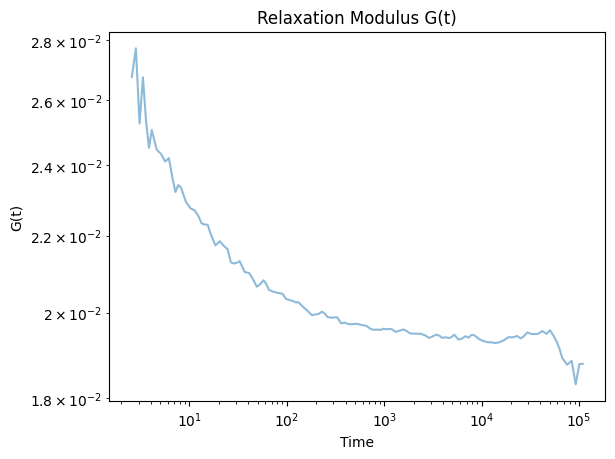

In [43]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


file = f"logs/press_50_spacing4_seed100.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
start = 37

data = data[start:].reset_index(drop=True)

t = data['time'].to_numpy()

G_t = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
        (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

# replace negative with NaN
G_t = np.where(G_t < 0, np.nan, G_t)


G_t *= 30**3 / (1.0 * 0.6)  # V / (kB * T)

# print(data.head())
# print(G_t.min(), G_t.max())

plt.loglog(t[start:], G_t[start:], alpha=0.5, label='G(t) data')
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Relaxation Modulus G(t)')
plt.show()


omega: 1.00e-07, G': nan
omega: 2.04e-07, G': nan
omega: 4.18e-07, G': nan
omega: 8.53e-07, G': nan
omega: 1.74e-06, G': nan
omega: 3.56e-06, G': nan
omega: 7.28e-06, G': nan
omega: 1.49e-05, G': nan
omega: 3.04e-05, G': nan
omega: 6.21e-05, G': nan
omega: 1.27e-04, G': nan
omega: 2.59e-04, G': nan
omega: 5.30e-04, G': nan
omega: 1.08e-03, G': nan
omega: 2.21e-03, G': nan
omega: 4.52e-03, G': nan
omega: 9.24e-03, G': nan
omega: 1.89e-02, G': nan
omega: 3.86e-02, G': nan
omega: 7.88e-02, G': nan
omega: 1.61e-01, G': nan
omega: 3.29e-01, G': nan
omega: 6.72e-01, G': nan
omega: 1.37e+00, G': nan
omega: 2.81e+00, G': nan
omega: 5.74e+00, G': nan
omega: 1.17e+01, G': nan
omega: 2.40e+01, G': nan
omega: 4.89e+01, G': nan
omega: 1.00e+02, G': nan


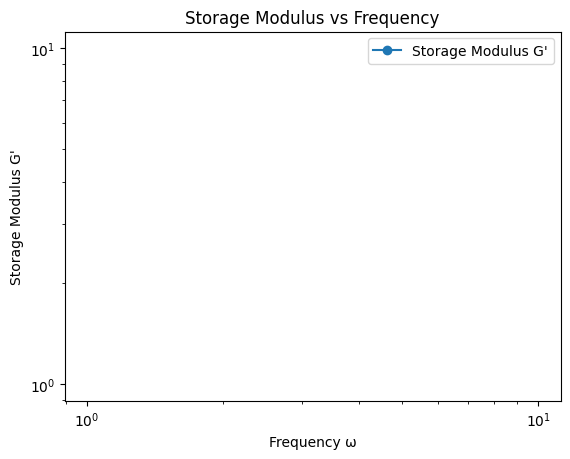

In [ ]:
storage_moduli = []

# n data points
n = 100
omega = np.logspace(-7, 2, n)

for w in omega:
    storage_moduli.append(storage_modulus(w, G_t, t, integration_points=5000))
    print(f"omega: {w:.2e}, G': {storage_moduli[-1]:.4f}")

plt.loglog(omega, storage_moduli, marker='o', label="Storage Modulus G'")
plt.xlabel('Frequency ω')
plt.ylabel("Storage Modulus G'")
plt.title("Storage Modulus vs Frequency")
plt.legend()
plt.show()

# storage_modulus(3, G_t, t, integration_points=5000)